**Setup Cell**

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

# Base project directory
BASE_DIR = Path("/content/drive/MyDrive/smart-waste-image-classifier")

# Main data directory (IMPORTANT)
DATA_DIR = BASE_DIR / "data"

# Optional (still fine to keep)
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"

DATA_DIR



Mounted at /content/drive


PosixPath('/content/drive/MyDrive/smart-waste-image-classifier/data')

In [ ]:
!pip install -U fastai timm


**Dataloaders**

In [ ]:
from fastai.vision.all import *


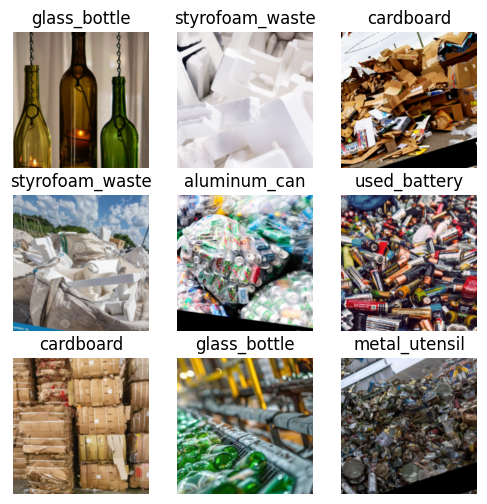

In [ ]:
dls = ImageDataLoaders.from_folder(
    DATA_DIR,
    train='train',
    valid='valid',
    item_tfms=Resize(256),
    batch_tfms=aug_transforms(
        do_flip=True,
        max_rotate=30,
        max_zoom=1.2,
        max_lighting=0.4,
        max_warp=0.2
    ),
    bs=32
)

dls.show_batch(max_n=9, figsize=(6,6))


**MODEL 1: CNN (ResNet18 Baseline - Transfer Learning)**

In [ ]:
learn_cnn = cnn_learner(
    dls,
    resnet18,
    metrics=accuracy
)

learn_cnn.fine_tune(10)

epoch,train_loss,valid_loss,accuracy,time
0,3.050668,1.319647,0.650888,00:28


epoch,train_loss,valid_loss,accuracy,time
0,1.464762,1.159263,0.650888,00:28
1,1.259897,0.895245,0.745562,00:30
2,1.058399,0.828273,0.798817,00:28
3,0.887892,0.837627,0.769231,00:28
4,0.713396,0.856393,0.769231,00:28
5,0.556132,0.829375,0.775148,00:28
6,0.458036,0.814199,0.775148,00:27
7,0.384328,0.770818,0.792899,00:27
8,0.339344,0.751669,0.786982,00:27
9,0.290843,0.747371,0.798817,00:27


In [ ]:
cnn_acc = learn_cnn.validate()[1]
print("ResNet18 CNN Accuracy:", cnn_acc)

ResNet18 CNN Accuracy: 0.7988165616989136


In [ ]:
learn_cnn.export("baseline_resnet18.pkl")

**MODEL 2 — ResNet50**

In [ ]:
learn_resnet = vision_learner(
    dls,
    resnet50,
    metrics=accuracy
)

learn_resnet.fine_tune(10)


epoch,train_loss,valid_loss,accuracy,time
0,2.622537,1.005682,0.674556,00:29


epoch,train_loss,valid_loss,accuracy,time
0,0.896746,0.799964,0.745562,00:30
1,0.752578,0.791135,0.751479,00:32
2,0.662063,0.738544,0.792899,00:29
3,0.540111,0.724691,0.810651,00:30
4,0.445825,0.755118,0.834320,00:29
5,0.369024,0.747451,0.822485,00:29
6,0.296147,0.770368,0.798817,00:29
7,0.241349,0.706932,0.822485,00:30
8,0.198427,0.693169,0.834320,00:29
9,0.180878,0.683020,0.828402,00:29


In [ ]:
resnet_acc = learn_resnet.validate()[1]
resnet_acc


0.8284023404121399

In [ ]:
learn_resnet.export("resnet50.pkl")


**MODEL 3 — EfficientNet-B0**

In [ ]:
learn_eff = vision_learner(
    dls,
    'efficientnet_b0',
    metrics=accuracy,
    pretrained=True
)

learn_eff.fit_one_cycle(5, 3e-3)

learn_eff.unfreeze()
learn_eff.fit_one_cycle(10, lr_max=slice(1e-4, 1e-3))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,accuracy,time
0,2.788392,1.163618,0.650888,00:28
1,1.803613,1.116961,0.715976,00:27
2,1.281696,0.911007,0.727811,00:27
3,0.956259,0.898805,0.733728,00:28
4,0.752560,0.924363,0.733728,00:28


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e8a6bf1f920>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


epoch,train_loss,valid_loss,accuracy,time
0,0.390248,0.888596,0.739645,00:28
1,0.377325,0.900726,0.733728,00:28
2,0.339117,0.894169,0.786982,00:28
3,0.312612,1.041950,0.751479,00:28
4,0.282553,1.041651,0.739645,00:28
5,0.239849,1.054798,0.727811,00:28
6,0.218998,1.057036,0.745562,00:29
7,0.197491,1.010124,0.745562,00:29
8,0.177311,1.022379,0.733728,00:29
9,0.153688,1.048588,0.727811,00:28


In [ ]:
eff_acc = learn_eff.validate()[1]
eff_acc


0.7278106212615967

In [ ]:
learn_eff.export("efficientnet_b0.pkl")


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Baseline CNN (ResNet18)",
        "ResNet50",
        "EfficientNet-B0"
    ],
    "Validation Accuracy": [
        cnn_acc,
        resnet_acc,
        eff_acc
    ]
})

results


,Model,Validation Accuracy
0,Baseline CNN (ResNet18),0.798817
1,ResNet50,0.828402
2,EfficientNet-B0,0.727811


In [ ]:
# Load the trained model
learn_resnet = load_learner(
    "/content/drive/MyDrive/smart-waste-image-classifier/data/resnet50.pkl",
    cpu=True
)

# Re-export safely for deployment
learn_resnet.export("resnet50_deploy.pkl")


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
